# 🧳 Capstone Project — NLP for the Travel Business

In this final project, you’ll play the role of a **data scientist for a travel company**
(hostel chain / small travel agency). You’ll work with **customer reviews & messages**
and build an end-to-end NLP pipeline:

1. **Load & explore data** (reviews + metadata).
2. **Clean & normalize text** (Part 1).
3. **Extract structured info with spaCy** (entities, nights, destinations) (Part 2).
4. **Vectorize text with Count/TF-IDF** (Part 3).
5. **Run sentiment analysis with VADER** (Part 4).
6. **Train a text classifier (Naive Bayes)** for review sentiment (Part 5).
7. **Discover topics with topic modeling (NMF)** (Part 6).
8. Combine everything into **business insights** and a simple **“insight function”**
   for new incoming messages.

You can:
- Use the **toy dataset** in this notebook (fully self-contained), or  
- Replace it with your own CSV of real reviews/messages.

> 💡 **Goal**: at the end, you should be able to answer business questions like:
> - “Which cities/channels have the most negative sentiment?”
> - “What are the main complaint topics?”
> - “Given a new message, what is its sentiment, category, and key entities?”


> ⚠️ Notes on the dataset and results  
> In this notebook we work with a **small, synthetic dataset** of travel reviews and messages, mainly for teaching the NLP pipeline (cleaning, vectorization, sentiment, classification, topic modeling).  
> Because the dataset is small and not from a real production system, the **evaluation metrics (accuracy, precision, recall, F1)** are **not necessarily perfect or stable**.  
> The goal here is to understand the **end-to-end workflow** and how each NLP component fits together, not to build a state-of-the-art model.  
> With more real data, the same pipeline can be retrained and tuned to achieve more reliable performance.



In [ ]:
# =========================================
# 0) Setup: imports and sample travel data
# =========================================

# If running in Colab, uncomment these if needed:
!pip install -q pandas numpy scikit-learn nltk spacy vaderSentiment
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import nltk

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

import spacy
from spacy.matcher import Matcher
from spacy.pipeline import EntityRuler

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import NMF

# Download NLTK resources (run once)
nltk.download("punkt")
nltk.download("punkt_tab")  # needed for newer NLTK versions
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")



# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# -------------------------------
# Sample travel reviews/messages
# -------------------------------
data = [
    {
        "text": "Amazing location in Barcelona, super clean rooms and friendly staff. I’ll definitely come back!",
        "rating": 5,
        "channel": "Booking",
        "city": "Barcelona"
    },
    {
        "text": "The hostel in Tokyo was noisy at night and the bathroom was not very clean.",
        "rating": 2,
        "channel": "Hostelworld",
        "city": "Tokyo"
    },
    {
        "text": "Great value for money, comfy bed and nice common area in Osaka.",
        "rating": 4,
        "channel": "Booking",
        "city": "Osaka"
    },
    {
        "text": "Terrible Wi-Fi and rude receptionist, I would not recommend this place at all.",
        "rating": 1,
        "channel": "Google Reviews",
        "city": "Barcelona"
    },
    {
        "text": "Loved the vibe in Kyoto, staff organized free walking tours and bar crawls.",
        "rating": 5,
        "channel": "Instagram DM",
        "city": "Kyoto"
    },
    {
        "text": "Room was tiny but very clean. Great for one or two nights in Shibuya.",
        "rating": 4,
        "channel": "Booking",
        "city": "Tokyo"
    },
    {
        "text": "Check-in was super slow and they lost my reservation. The kitchen was dirty too.",
        "rating": 2,
        "channel": "Email",
        "city": "Osaka"
    },
    {
        "text": "Fantastic staff and perfect location near La Rambla. A bit noisy but overall great stay.",
        "rating": 4,
        "channel": "Booking",
        "city": "Barcelona"
    },

    # --- Booking / website chat requests (unrated) ---
    {
        "text": "I need a cheap private room in Osaka for 3 nights, ideally with breakfast included.",
        "rating": None,
        "channel": "Website Chat",
        "city": None
    },
    {
        "text": "Looking for a dorm bed in Kyoto next weekend, close to the station, budget around 25 euros per night.",
        "rating": None,
        "channel": "Website Chat",
        "city": None
    },

    # --- More positive reviews ---
    {
        "text": "Super friendly staff and great social events, I met so many people at this hostel in Barcelona.",
        "rating": 5,
        "channel": "Hostelworld",
        "city": "Barcelona"
    },
    {
        "text": "The hostel in Tokyo was spotless, comfortable beds and amazing showers.",
        "rating": 5,
        "channel": "Booking",
        "city": "Tokyo"
    },
    {
        "text": "Great location in Osaka, walking distance to everything and the staff helped with restaurant recommendations.",
        "rating": 4,
        "channel": "Google Reviews",
        "city": "Osaka"
    },
    {
        "text": "Really nice atmosphere in Kyoto, quiet at night and the garden view was beautiful.",
        "rating": 5,
        "channel": "Booking",
        "city": "Kyoto"
    },
    {
        "text": "Loved the common area and kitchen, everything felt new and very clean.",
        "rating": 5,
        "channel": "Hostelworld",
        "city": "Tokyo"
    },
    {
        "text": "The staff went above and beyond to help me print tickets and plan my day trips around Osaka.",
        "rating": 5,
        "channel": "Email",
        "city": "Osaka"
    },
    {
        "text": "Nice rooftop terrace and bar in Barcelona, perfect for meeting other travelers.",
        "rating": 4,
        "channel": "Instagram DM",
        "city": "Barcelona"
    },
    {
        "text": "Comfy beds, good lockers and fast Wi-Fi, I would happily stay here again in Kyoto.",
        "rating": 4,
        "channel": "Booking",
        "city": "Kyoto"
    },

    # --- More negative reviews ---
    {
        "text": "The room in Barcelona was freezing, the heater didn’t work and nobody at reception cared.",
        "rating": 1,
        "channel": "Google Reviews",
        "city": "Barcelona"
    },
    {
        "text": "Very dirty bathrooms in Osaka, hair everywhere and bad smell all the time.",
        "rating": 1,
        "channel": "Booking",
        "city": "Osaka"
    },
    {
        "text": "Extremely loud at night in Tokyo, people shouting in the hallway and no staff to stop them.",
        "rating": 2,
        "channel": "Hostelworld",
        "city": "Tokyo"
    },
    {
        "text": "Beds were uncomfortable and the sheets didn’t feel clean, not a good experience in Kyoto.",
        "rating": 2,
        "channel": "Google Reviews",
        "city": "Kyoto"
    },
    {
        "text": "Check-in took more than 40 minutes, and the receptionist was very rude and unhelpful.",
        "rating": 1,
        "channel": "Booking",
        "city": "Barcelona"
    },
    {
        "text": "Wifi kept disconnecting and I couldn’t work, I chose this place in Tokyo because it advertised coworking.",
        "rating": 2,
        "channel": "Email",
        "city": "Tokyo"
    },
    {
        "text": "Kitchen was messy, dishes piled up and no one cleaned for two days in Osaka.",
        "rating": 2,
        "channel": "Hostelworld",
        "city": "Osaka"
    },

    # --- Some more neutral / mixed reviews ---
    {
        "text": "Good location in Barcelona but the rooms were very small and there was no common area.",
        "rating": 3,
        "channel": "Booking",
        "city": "Barcelona"
    },
    {
        "text": "Average stay in Kyoto, nothing terrible but nothing special either.",
        "rating": 3,
        "channel": "Google Reviews",
        "city": "Kyoto"
    },
    {
        "text": "Decent value for the price in Tokyo, but the walls are thin and you can hear your neighbors.",
        "rating": 3,
        "channel": "Booking",
        "city": "Tokyo"
    },

    # --- More unrated requests/messages ---
    {
        "text": "Do you have any female-only dorms available in Kyoto next Friday and Saturday?",
        "rating": None,
        "channel": "Email",
        "city": None
    },
    {
        "text": "Can I book a quiet private room in Tokyo for one week with a good desk for working?",
        "rating": None,
        "channel": "Website Chat",
        "city": None
    },
    {
        "text": "Looking for a hostel in Barcelona close to the beach, preferably with a bar and social events.",
        "rating": None,
        "channel": "Instagram DM",
        "city": None
    }
]

df = pd.DataFrame(data)
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,text,rating,channel,city
0,"Amazing location in Barcelona, super clean roo...",5.0,Booking,Barcelona
1,The hostel in Tokyo was noisy at night and the...,2.0,Hostelworld,Tokyo
2,"Great value for money, comfy bed and nice comm...",4.0,Booking,Osaka
3,"Terrible Wi-Fi and rude receptionist, I would ...",1.0,Google Reviews,Barcelona
4,"Loved the vibe in Kyoto, staff organized free ...",5.0,Instagram DM,Kyoto
5,Room was tiny but very clean. Great for one or...,4.0,Booking,Tokyo
6,Check-in was super slow and they lost my reser...,2.0,Email,Osaka
7,Fantastic staff and perfect location near La R...,4.0,Booking,Barcelona
8,I need a cheap private room in Osaka for 3 nig...,NaN,Website Chat,None
9,"Looking for a dorm bed in Kyoto next weekend, ...",NaN,Website Chat,None


## 1) Quick Exploratory Data Analysis

First, let’s understand what we have:
- A mix of **reviews** (with numeric rating) and **booking/chat requests** (no rating).
- Metadata: **channel** and **city**.
- We’ll treat rows with `rating` as **labeled reviews**, others as **messages/queries**.


In [ ]:
df.info()
print("\nSample rows:\n")
print(df.head())

print("\nRatings distribution (only rated rows):")
print(df["rating"].value_counts(dropna=True))

print("\nChannels:", df["channel"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   text     31 non-null     object 
 1   rating   26 non-null     float64
 2   channel  31 non-null     object 
 3   city     26 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.1+ KB

Sample rows:

                                                text  rating         channel  \
0  Amazing location in Barcelona, super clean roo...     5.0         Booking   
1  The hostel in Tokyo was noisy at night and the...     2.0     Hostelworld   
2  Great value for money, comfy bed and nice comm...     4.0         Booking   
3  Terrible Wi-Fi and rude receptionist, I would ...     1.0  Google Reviews   
4  Loved the vibe in Kyoto, staff organized free ...     5.0    Instagram DM   

        city  
0  Barcelona  
1      Tokyo  
2      Osaka  
3  Barcelona  
4      Kyoto  

Ratings distribution (only rate

## 2) Text Cleaning & Normalization (Part 1 recap)

We’ll build a **cleaning pipeline** similar to Part 1:
- Lowercasing
- Removing URLs, HTML, digits, and extra punctuation
- Tokenization
- Stop-word removal
- Lemmatization

We’ll keep both:
- `text` (raw text, useful for VADER), and
- `clean_text` (normalized version, useful for ML models).

In [ ]:
# Map POS tags (simplified) for WordNet lemmatizer
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""

    # 1) Lowercase
    text = text.lower()

    # 2) Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3) Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # 4) Keep letters and basic punctuation
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5) Tokenize
    tokens = nltk.word_tokenize(text)

    # 6) Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 7) POS tagging for better lemmatization
    pos_tags = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(pos)) for w, pos in pos_tags]

    return " ".join(lemmas)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]]



,text,clean_text
0,"Amazing location in Barcelona, super clean roo...",amaze location barcelona super clean room frie...
1,The hostel in Tokyo was noisy at night and the...,hostel tokyo noisy night bathroom clean
2,"Great value for money, comfy bed and nice comm...",great value money comfy bed nice common area o...
3,"Terrible Wi-Fi and rude receptionist, I would ...",terrible rude receptionist would recommend place
4,"Loved the vibe in Kyoto, staff organized free ...",love vibe kyoto staff organize free walking to...
5,Room was tiny but very clean. Great for one or...,room tiny clean great one two night shibuya
6,Check-in was super slow and they lost my reser...,check super slow lose reservation kitchen dirty
7,Fantastic staff and perfect location near La R...,fantastic staff perfect location near rambla b...
8,I need a cheap private room in Osaka for 3 nig...,need cheap private room osaka night ideally br...
9,"Looking for a dorm bed in Kyoto next weekend, ...",look dorm bed kyoto next weekend close station...


## 3) Extracting Structured Info with spaCy (Part 2 recap)

We’ll use spaCy to:
- Extract standard entities (**GPE**, **LOC**, **MONEY**, **DATE**, etc.).
- Add a custom **`DESTINATION`** label for some common travel spots.
- Use pattern matching to detect **number of nights** and **room types** in chat messages.

Goal: turn free text like  
> "_cheap private room in Osaka for 3 nights_"  
into structured info:
- city = Osaka  
- room_type = private room  
- nights = 3

In [ ]:
def inspect_doc(text):
    doc = nlp(text)
    print(f"TEXT: {text}")
    print("ENTITIES:", [(ent.text, ent.label_) for ent in doc.ents])
    print("NOUN CHUNKS:", [chunk.text for chunk in doc.noun_chunks])
    print("-" * 60)

for t in df["text"].head(5):
    inspect_doc(t)

TEXT: Amazing location in Barcelona, super clean rooms and friendly staff. I’ll definitely come back!
ENTITIES: [('Barcelona', 'GPE')]
NOUN CHUNKS: ['Amazing location', 'Barcelona', 'super clean rooms', 'friendly staff', 'I']
------------------------------------------------------------
TEXT: The hostel in Tokyo was noisy at night and the bathroom was not very clean.
ENTITIES: [('Tokyo', 'GPE'), ('night', 'TIME')]
NOUN CHUNKS: ['The hostel', 'Tokyo', 'night', 'the bathroom']
------------------------------------------------------------
TEXT: Great value for money, comfy bed and nice common area in Osaka.
ENTITIES: [('Osaka', 'GPE')]
NOUN CHUNKS: ['Great value', 'money', 'bed', 'nice common area', 'Osaka']
------------------------------------------------------------
TEXT: Terrible Wi-Fi and rude receptionist, I would not recommend this place at all.
ENTITIES: []
NOUN CHUNKS: ['I', 'this place']
------------------------------------------------------------
TEXT: Loved the vibe in Kyoto, sta

In [ ]:
# Add custom DESTINATION labels
ruler = nlp.add_pipe("entity_ruler", before="ner", config={"overwrite_ents": True})
destination_patterns = [
    {"label": "DESTINATION", "pattern": "Barcelona"},
    {"label": "DESTINATION", "pattern": "Tokyo"},
    {"label": "DESTINATION", "pattern": "Osaka"},
    {"label": "DESTINATION", "pattern": "Kyoto"},
    {"label": "DESTINATION", "pattern": "Shibuya"},
    {"label": "DESTINATION", "pattern": "La Rambla"},
]
ruler.add_patterns(destination_patterns)

# Matcher for nights (e.g. "3 nights", "two nights")
matcher = Matcher(nlp.vocab)
pattern_nights = [
    [{"LIKE_NUM": True}, {"LOWER": {"IN": ["night", "nights"]}}],
]
matcher.add("NIGHTS", pattern_nights)

# Simple pattern for room types
room_keywords = ["dorm", "dorm bed", "private room", "single room", "double room"]
# We'll just check if these substrings appear in the text.

def extract_structured_info(text):
    doc = nlp(text)
    ents = [(ent.text, ent.label_) for ent in doc.ents]

    # Destination (our custom or GPE)
    dests = [ent.text for ent in doc.ents if ent.label_ in ["DESTINATION", "GPE", "LOC"]]
    destination = dests[0] if dests else None

    # Nights via matcher
    matches = matcher(doc)
    nights = None
    for match_id, start, end in matches:
        span = doc[start:end]
        try:
            nights = int(span[0].text)
        except ValueError:
            pass

    # Room type via keyword search (very simple)
    text_lower = text.lower()
    room_type = None
    for kw in room_keywords:
        if kw in text_lower:
            room_type = kw
            break

    return pd.Series({
        "entities": ents,
        "destination_extracted": destination,
        "nights_extracted": nights,
        "room_type_extracted": room_type,
    })

structured_cols = df["text"].apply(extract_structured_info)
df = pd.concat([df, structured_cols], axis=1)
df[["text", "destination_extracted", "nights_extracted", "room_type_extracted"]]

,text,destination_extracted,nights_extracted,room_type_extracted
0,"Amazing location in Barcelona, super clean roo...",Barcelona,NaN,None
1,The hostel in Tokyo was noisy at night and the...,Tokyo,NaN,None
2,"Great value for money, comfy bed and nice comm...",Osaka,NaN,None
3,"Terrible Wi-Fi and rude receptionist, I would ...",None,NaN,None
4,"Loved the vibe in Kyoto, staff organized free ...",Kyoto,NaN,None
5,Room was tiny but very clean. Great for one or...,Shibuya,NaN,None
6,Check-in was super slow and they lost my reser...,None,NaN,None
7,Fantastic staff and perfect location near La R...,La Rambla,NaN,None
8,I need a cheap private room in Osaka for 3 nig...,Osaka,3.0,private room
9,"Looking for a dorm bed in Kyoto next weekend, ...",Kyoto,NaN,dorm


## 4) Vectorizing Clean Text (Part 3 recap)

We’ll convert `clean_text` into numeric features using:
- **CountVectorizer** (bag-of-words)
- **TfidfVectorizer**

We’ll keep the TF-IDF matrix as our main representation for:
- **Classification**
- **Topic modeling**

In [ ]:
# Only use rows that have some text (all rows should, but just in case)
mask_nonempty = df["clean_text"].str.len() > 0
df_model = df[mask_nonempty].copy()

# CountVectorizer (for illustration)
cv = CountVectorizer(min_df=1, ngram_range=(1, 2))
X_counts = cv.fit_transform(df_model["clean_text"])

print("Counts shape:", X_counts.shape)
print("Sample vocabulary (first 20):", list(cv.get_feature_names_out()[:20]))

# TF-IDF (main representation)
tfidf = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df_model["clean_text"])
print("TF-IDF shape:", X_tfidf.shape)

Counts shape: (31, 390)
Sample vocabulary (first 20): ['advertise', 'advertise coworking', 'amaze', 'amaze location', 'amaze shower', 'area', 'area kitchen', 'area osaka', 'around', 'around euro', 'around osaka', 'atmosphere', 'atmosphere kyoto', 'available', 'available kyoto', 'average', 'average stay', 'back', 'bad', 'bad smell']
TF-IDF shape: (31, 390)


## 5) Sentiment Analysis with VADER (Part 4 recap)

For all rows (reviews + messages), we’ll:
- Apply **VADER** on the **raw `text`**.
- Use the **compound** score.
- Convert it into **Positive / Neutral / Negative** labels.

Then we’ll:
- Compare VADER sentiment vs. numeric ratings (where available).
- Aggregate sentiment by **city** and **channel** to simulate business KPIs.

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text):
    if pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(text)["compound"]

df["compound"] = df["text"].apply(vader_compound)

def label_from_compound(c):
    if c >= 0.5:
        return "positive"
    elif c <= -0.5:
        return "negative"
    else:
        return "neutral"

df["vader_sentiment"] = df["compound"].apply(label_from_compound)
df[["text", "compound", "vader_sentiment", "rating"]]

,text,compound,vader_sentiment,rating
0,"Amazing location in Barcelona, super clean roo...",0.9485,positive,5.0
1,The hostel in Tokyo was noisy at night and the...,-0.4896,neutral,2.0
2,"Great value for money, comfy bed and nice comm...",0.8519,positive,4.0
3,"Terrible Wi-Fi and rude receptionist, I would ...",-0.8025,negative,1.0
4,"Loved the vibe in Kyoto, staff organized free ...",0.8020,positive,5.0
5,Room was tiny but very clean. Great for one or...,0.9013,positive,4.0
6,Check-in was super slow and they lost my reser...,-0.0772,neutral,2.0
7,Fantastic staff and perfect location near La R...,0.8735,positive,4.0
8,I need a cheap private room in Osaka for 3 nig...,0.4215,neutral,NaN
9,"Looking for a dorm bed in Kyoto next weekend, ...",0.0000,neutral,NaN


vader_sentiment
neutral     14
positive    12
negative     5
Name: count, dtype: int64


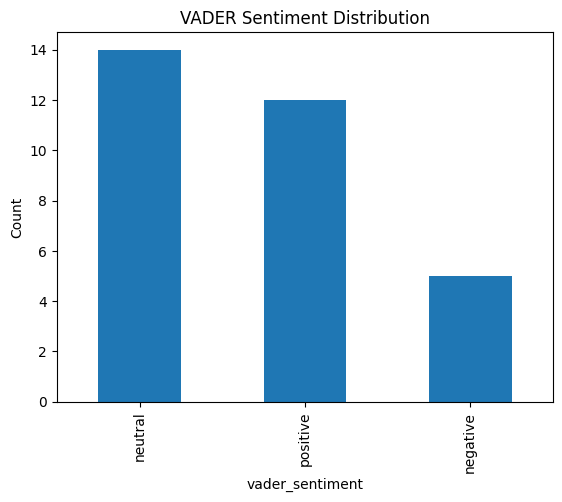


Mean rating by VADER label:
vader_sentiment
negative    1.400000
neutral     2.555556
positive    4.500000
Name: rating, dtype: float64


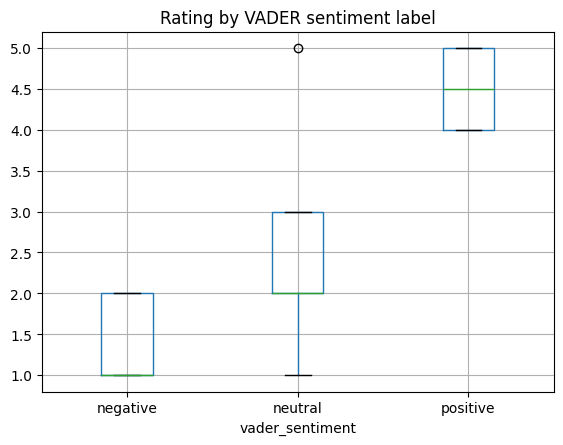

In [ ]:
# Sentiment counts
sent_counts = df["vader_sentiment"].value_counts()
print(sent_counts)

sent_counts.plot(kind="bar")
plt.title("VADER Sentiment Distribution")
plt.ylabel("Count")
plt.show()

# Compare average rating by VADER sentiment (only where rating exists)
rated = df.dropna(subset=["rating"])
print("\nMean rating by VADER label:")
print(rated.groupby("vader_sentiment")["rating"].mean())

rated.boxplot(column="rating", by="vader_sentiment")
plt.suptitle("")
plt.title("Rating by VADER sentiment label")
plt.show()

## 6) Text Classification — Predicting Review Sentiment (Part 5 recap)

We’ll build a simple **text classifier** to predict whether a review is:
- **Positive** (rating ≥ 4)
- **Negative** (rating ≤ 2)

Steps:
1. Keep only rows with numeric ratings.
2. Create a binary label: `y = positive / negative` (drop neutrals for simplicity).
3. Use `clean_text` + **TF-IDF** vectorization.
4. Train a **Multinomial Naive Bayes** classifier.
5. Evaluate accuracy and show the **classification report**.

In [ ]:
# Subset to reviews with ratings
reviews = df.dropna(subset=["rating"]).copy()

# Create label: positive (>=4) vs negative (<=2). Drop rating=3 if present.
def rating_to_label(r):
    if r >= 4:
        return "positive"
    elif r <= 2:
        return "negative"
    else:
        return None

reviews["label"] = reviews["rating"].apply(rating_to_label)
reviews = reviews.dropna(subset=["label"])
reviews[["text", "rating", "label"]]

,text,rating,label
0,"Amazing location in Barcelona, super clean roo...",5.0,positive
1,The hostel in Tokyo was noisy at night and the...,2.0,negative
2,"Great value for money, comfy bed and nice comm...",4.0,positive
3,"Terrible Wi-Fi and rude receptionist, I would ...",1.0,negative
4,"Loved the vibe in Kyoto, staff organized free ...",5.0,positive
5,Room was tiny but very clean. Great for one or...,4.0,positive
6,Check-in was super slow and they lost my reser...,2.0,negative
7,Fantastic staff and perfect location near La R...,4.0,positive
10,"Super friendly staff and great social events, ...",5.0,positive
11,"The hostel in Tokyo was spotless, comfortable ...",5.0,positive


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter


# Vectorize clean_text for classification
tfidf_clf = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
X = tfidf_clf.fit_transform(reviews["clean_text"])
y = reviews["label"].values

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train Naive Bayes classifier
clf = MultinomialNB(alpha=1.0)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# class distribution in test set
unique, counts = np.unique(y_test, return_counts=True)
print("Test set class distribution:", dict(zip(unique, counts)))

# --- Majority-class baseline for comparison ---
train_counts = Counter(y_train)
majority_class = train_counts.most_common(1)[0][0]
baseline_pred = [majority_class] * len(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"\nMajority baseline (always predicts '{majority_class}') accuracy: {baseline_acc:.3f}")

# --- Model performance ---
model_acc = accuracy_score(y_test, y_pred)
print(f"\nNaive Bayes accuracy: {model_acc:.3f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))



Test set class distribution: {'negative': np.int64(3), 'positive': np.int64(4)}

Majority baseline (always predicts 'positive') accuracy: 0.571

Naive Bayes accuracy: 0.714

Classification report:

              precision    recall  f1-score   support

    negative       1.00      0.33      0.50         3
    positive       0.67      1.00      0.80         4

    accuracy                           0.71         7
   macro avg       0.83      0.67      0.65         7
weighted avg       0.81      0.71      0.67         7


Confusion matrix:
[[1 2]
 [0 4]]


In [ ]:
# Inspect top features per class (like in Part 5)
feature_names = np.array(tfidf_clf.get_feature_names_out())
class_labels = clf.classes_
n_top = 10

for i, class_label in enumerate(class_labels):
    class_prob = clf.feature_log_prob_[i]
    top_idx = np.argsort(class_prob)[-n_top:]
    print(f"\nTop terms for class '{class_label}':")
    print(feature_names[top_idx])


Top terms for class 'negative':
['terrible' 'receptionist would' 'bathroom clean' 'bathroom'
 'hostel tokyo' 'noisy night' 'night bathroom' 'hostel' 'tokyo'
 'tokyo noisy']

Top terms for class 'positive':
['night shibuya' 'one' 'shibuya' 'room tiny' 'one two' 'tiny' 'tiny clean'
 'clean' 'great' 'room']


## 7) Topic Modeling on Negative Reviews (Part 6 recap)

Now we look for **themes in the complaints**.

1. Take only **negative reviews** (by VADER or by rating).
2. Use **TF-IDF** on `clean_text`.
3. Run **NMF** with a small number of topics (e.g., 2–4).
4. Inspect **top words per topic** and try to give them human labels
   (e.g., “Cleanliness”, “Staff & Service”, “Noise”, “Wi-Fi”).

This is a **lightweight version** of what you did in Part 6 (NMF, LDA, BERTopic, …).

In [ ]:
# Choose negative reviews based on rating label (built earlier in reviews df)
neg_reviews = reviews[reviews["label"] == "negative"].copy()

if len(neg_reviews) < 2:
    print("Not enough negative reviews for topic modeling in this tiny toy dataset.")
else:
    # Vectorize
    tfidf_topics = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
    X_topics = tfidf_topics.fit_transform(neg_reviews["clean_text"])

    n_topics = 2  # you can play with this
    nmf_model = NMF(n_components=n_topics, random_state=42)
    W = nmf_model.fit_transform(X_topics)
    H = nmf_model.components_

    vocab = np.array(tfidf_topics.get_feature_names_out())

    def print_topics(H, vocab, topn=10):
        for topic_idx, topic_vec in enumerate(H):
            top_idx = np.argsort(topic_vec)[-topn:]
            print(f"\nTopic {topic_idx}:")
            print(", ".join(vocab[top_idx]))

    print_topics(H, vocab, topn=10)

    # Attach dominant topic to each negative review
    neg_reviews["topic_idx"] = W.argmax(axis=1)
    print("\nNegative reviews with their inferred topic:")
    from IPython.display import display
    display(neg_reviews[["text", "topic_idx"]])


Topic 0:
noisy, night bathroom, night, bathroom, clean, noisy night, hostel tokyo, tokyo, hostel, tokyo noisy

Topic 1:
recommend place, receptionist would, recommend, receptionist, rude receptionist, terrible, place, terrible rude, would, would recommend

Negative reviews with their inferred topic:


,text,topic_idx
1,The hostel in Tokyo was noisy at night and the...,0
3,"Terrible Wi-Fi and rude receptionist, I would ...",1
6,Check-in was super slow and they lost my reser...,0


## 8) End-to-end Pipeline for a New Message

Let’s wrap everything into a single helper function that, given a new incoming message:

1. Runs **cleaning** and **VADER**.
2. Extracts **destination, nights, room type** with spaCy + patterns.
3. Uses the **Naive Bayes classifier** (if it’s a review) to estimate sentiment.
4. Returns a small **JSON-like summary** that a travel agent or dashboard could use.

> In a real product, this would sit behind an API and feed into a CRM or internal tool.

In [ ]:
def analyze_message(text):
    # 1) Cleaning & TF-IDF (for classifier)
    clean = clean_text(text)

    # 2) VADER
    compound = vader_compound(text)
    vader_label = label_from_compound(compound)

    # 3) spaCy structured info
    info = extract_structured_info(text)

    # 4) Naive Bayes prediction (only if we have a non-empty clean_text and classifier is trained)
    clf_label = None
    clf_proba = None
    if clean.strip():
        X_new = tfidf_clf.transform([clean])
        clf_label = clf.predict(X_new)[0]
        if hasattr(clf, "predict_proba"):
            probs = clf.predict_proba(X_new)[0]
            clf_proba = dict(zip(clf.classes_, probs.round(3)))

    return {
        "text": text,
        "clean_text": clean,
        "vader_compound": compound,
        "vader_label": vader_label,
        "destination_extracted": info["destination_extracted"],
        "nights_extracted": info["nights_extracted"],
        "room_type_extracted": info["room_type_extracted"],
        "nb_predicted_label": clf_label,
        "nb_predicted_proba": clf_proba,
    }

# Try on a few custom messages
examples = [
    "I need a cheap dorm bed in Tokyo for 2 nights, near the station.",
    "The hostel was dirty and the staff were rude.",
    "Amazing location and super friendly staff, loved the bar crawl!",
]

for msg in examples:
    result = analyze_message(msg)
    print("\nMESSAGE:", msg)
    for k, v in result.items():
        print(f"  {k}: {v}")


MESSAGE: I need a cheap dorm bed in Tokyo for 2 nights, near the station.
  text: I need a cheap dorm bed in Tokyo for 2 nights, near the station.
  clean_text: need cheap dorm bed tokyo night near station
  vader_compound: 0.0
  vader_label: neutral
  destination_extracted: Tokyo
  nights_extracted: 2
  room_type_extracted: dorm
  nb_predicted_label: positive
  nb_predicted_proba: {np.str_('negative'): np.float64(0.433), np.str_('positive'): np.float64(0.567)}

MESSAGE: The hostel was dirty and the staff were rude.
  text: The hostel was dirty and the staff were rude.
  clean_text: hostel dirty staff rude
  vader_compound: -0.7096
  vader_label: negative
  destination_extracted: None
  nights_extracted: None
  room_type_extracted: None
  nb_predicted_label: positive
  nb_predicted_proba: {np.str_('negative'): np.float64(0.479), np.str_('positive'): np.float64(0.521)}

MESSAGE: Amazing location and super friendly staff, loved the bar crawl!
  text: Amazing location and super friendly 

## 9) Reflection & Possible Extensions

You’ve now combined **all previous parts** into one coherent project:

- **Part 1** — Cleaning & normalization → `clean_text`
- **Part 2** — spaCy NER & rules → destinations, nights, room type
- **Part 3** — Vectorization → TF-IDF matrices for models
- **Part 4** — VADER sentiment → quick sentiment scores & labels
- **Part 5** — Naive Bayes classification → predictive model for review polarity
- **Part 6** — Topic modeling (NMF) → complaint themes

### What you can try as next steps

1. **Replace the toy DataFrame with a real CSV**
   - e.g. columns: `text, rating, city, channel, date, property_name`.
2. **Improve the classifier**
   - Add more classes (e.g. 1–5 stars, or multiple intent categories).
   - Compare Naive Bayes with **Logistic Regression** or **Linear SVM**.
3. **Better topic modeling**
   - Use more reviews and experiment with **LDA** (Gensim) or **BERTopic**
     as in Part 6.
4. **Business dashboard**
   - Aggregate sentiment by **week/month** and **property**.
   - Track topics of negative reviews over time.
5. **Production mindset**
   - Wrap `analyze_message(...)` into an API.
   - Log predictions and manually review edge cases regularly.

> 🎯 **Deliverable idea for students:**  
> Build your own notebook (or mini-app) using a real dataset from a travel business,
> and present **3–5 concrete insights** + a short demo of your end-to-end pipeline.